# Titanic Survival Prediction

## Machine Learning Classification Project

This project uses the Titanic dataset to build a machine learning model that predicts whether a passenger survived the Titanic disaster.

**Model:** Logistic Regression  
**Libraries:** Python, Pandas, Scikit-learn  
**Accuracy:** 80.45%  
**F1 Score:** 72.44%


## 1. Project Objective

The objective of this project is to build a binary classification model that predicts whether a Titanic passenger survived based on passenger information.

The target variable is `survived`:

- `0` = Did not survive
- `1` = Survived

The model uses passenger class, age, number of siblings/spouses, number of parents/children, fare, sex, and port of embarkation as input features.

In [14]:
import pandas as pd
import seaborn as sns


In [15]:
df = sns.load_dataset("titanic")


In [16]:

df.head()



,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [17]:
df.shape



(891, 15)

In [18]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [19]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [20]:
df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


## 2. Data Preprocessing

The dataset was inspected for missing values and inappropriate data types.

- Missing `age` values were replaced with the median age.
- Missing `embarked` values were replaced with the most frequent category.
- Categorical variables (`sex` and `embarked`) were converted into numerical features using one-hot encoding.
- The `survived` column was separated as the target variable.

In [21]:
df = df[
    [
        "survived",
        "pclass",
        "sex",
        "age",
        "sibsp",
        "parch",
        "fare",
        "embarked"
    ]
]

In [22]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [23]:
df["age"] = df["age"].fillna(df["age"].median())

In [24]:
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

In [25]:
df.isnull().sum()


,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0


In [26]:
X = df.drop("survived", axis=1)
y = df["survived"]

In [27]:
X.head()
y.head()

,survived
0,0
1,1
2,1
3,1
4,0


In [28]:
X.dtypes

,0
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object


In [29]:
from sklearn.preprocessing import OneHotEncoder

In [30]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

In [31]:
encoded = encoder.fit_transform(X[["sex", "embarked"]])

In [32]:
encoded[:5]


array([[0., 1., 0., 0., 1.],
       [1., 0., 1., 0., 0.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 0., 1.],
       [0., 1., 0., 0., 1.]])

In [33]:
encoder.get_feature_names_out(["sex", "embarked"])

array(['sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S'],
      dtype=object)

In [35]:
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(["sex", "embarked"]),
    index=X.index
)
encoded_df.head()

,sex_female,sex_male,embarked_C,embarked_Q,embarked_S
0,0.0,1.0,0.0,0.0,1.0
1,1.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [36]:
X = X.drop(["sex", "embarked"], axis=1)

In [ ]:
X = X.drop(["sex", "embarked"], axis=1)

In [37]:
X = pd.concat([X, encoded_df], axis=1)

In [38]:
X.head()

,pclass,age,sibsp,parch,fare,sex_female,sex_male,embarked_C,embarked_Q,embarked_S
0,3,22.0,1,0,7.2500,0.0,1.0,0.0,0.0,1.0
1,1,38.0,1,0,71.2833,1.0,0.0,1.0,0.0,0.0
2,3,26.0,0,0,7.9250,1.0,0.0,0.0,0.0,1.0
3,1,35.0,1,0,53.1000,1.0,0.0,0.0,0.0,1.0
4,3,35.0,0,0,8.0500,0.0,1.0,0.0,0.0,1.0


In [39]:
X.shape

(891, 10)

In [40]:
X.dtypes

,0
pclass,int64
age,float64
sibsp,int64
parch,int64
fare,float64
sex_female,float64
sex_male,float64
embarked_C,float64
embarked_Q,float64
embarked_S,float64


In [41]:
from sklearn.model_selection import train_test_split


In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [44]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (712, 10)
X_test: (179, 10)
y_train: (712,)
y_test: (179,)


## 3. Model Training

The dataset was divided into training and testing sets using an 80/20 split.

Logistic Regression was selected as the baseline classification model because the target variable is binary: survived or did not survive.

A fixed random state was used to make the train/test split reproducible.

In [45]:
from sklearn.linear_model import LogisticRegression

In [46]:
model = LogisticRegression(max_iter=1000)

In [47]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [49]:
y_pred = model.predict(X_test)
y_pred[:20]

array([0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1])

In [51]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8044692737430168


In [52]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.7244094488188977


## 4. Model Evaluation

The trained model was evaluated on the unseen test dataset using accuracy and F1 score.

The model achieved:

- **Test Accuracy: 80.45%**
- **F1 Score: 72.44%**

Accuracy measures the overall proportion of correct predictions, while the F1 score provides a balance between precision and recall.

In [53]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("F1 Score:", f1)

Accuracy: 0.8044692737430168
F1 Score: 0.7244094488188977


## 5. Final Model with Leakage-Free Preprocessing

To avoid data leakage, preprocessing is performed as part of a machine learning pipeline.

The data is first divided into training and testing sets. The preprocessing steps are then fitted only on the training data and applied to both training and test data.

In [54]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [55]:
df_final = sns.load_dataset("titanic")

In [56]:
features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

target = "survived"

X_final = df_final[features]
y_final = df_final[target]

In [57]:
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final,
    y_final,
    test_size=0.2,
    random_state=42,
    stratify=y_final
)

In [58]:
numerical_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

In [59]:
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

In [60]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)


In [61]:
SimpleImputer(strategy="most_frequent")
OneHotEncoder(handle_unknown="ignore")

OneHotEncoder(handle_unknown='ignore')

In [62]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [63]:
final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

In [65]:
final_model.fit(X_train_final, y_train_final)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [66]:
y_pred_final = final_model.predict(X_test_final)

## 5. Model Performance

The final model is evaluated using accuracy, F1 score, and a confusion matrix.

The confusion matrix provides a more detailed view of the model's classification performance by showing correct and incorrect predictions for both classes.

In [67]:
final_accuracy = accuracy_score(y_test_final, y_pred_final)
final_f1 = f1_score(y_test_final, y_pred_final)

print("Final Test Accuracy:", final_accuracy)
print("Final F1 Score:", final_f1)

Final Test Accuracy: 0.8044692737430168
Final F1 Score: 0.7244094488188977


In [68]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [69]:
cm = confusion_matrix(y_test_final, y_pred_final)

print(cm)

[[98 12]
 [23 46]]


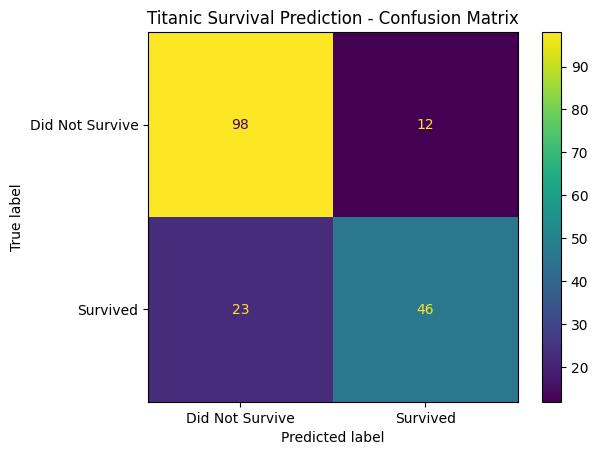

In [70]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Did Not Survive", "Survived"]
)

disp.plot()
plt.title("Titanic Survival Prediction - Confusion Matrix")
plt.show()

## 6. Conclusion

The Logistic Regression model achieved a test accuracy of 80.45% and an F1 score of 72.44% on the Titanic dataset.

The project demonstrates a complete machine learning workflow including data exploration, missing-value handling, categorical encoding, train/test splitting, model training, and evaluation.

A Scikit-learn Pipeline and ColumnTransformer were used to ensure preprocessing was fitted only on the training data and applied consistently to the test data.